<a href="https://colab.research.google.com/github/yanaguntikarmeesal/Agentic-AI-Learning-Assistant-project/blob/main/Agentic_AI_Learning_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Agentic AI Project Using Groq — Google Colab

Here is the complete Google Colab notebook code for an Agentic AI assistant using Groq + LangChain + one custom tool.

# Project features

1. Uses only Groq — no Gemini API required.

2. One custom tool for summarizing text and answering questions.

3. Uses a LangChain agent to decide when to call the tool.

4. Maintains conversation memory using a thread ID.

5. Includes an interactive chatbot.

# 1: Install Required Libraries

In [ ]:
%pip install -q -U langchain langchain-groq langgraph

# 2: Enter Your Groq API Key

In [ ]:
import os
from getpass import getpass

GROQ_API_KEY = getpass("Enter your Groq API key: ")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

print("Groq API key configured successfully!")

# 3: Import Libraries

In [ ]:
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# 4: Initialize the Groq Model

In [ ]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

print("Groq model initialized successfully!")

# 5: Create One Custom Tool

This single tool can summarize text or answer a question based on the task you provide.

In [ ]:
@tool
def text_assistant(task: str, text: str) -> str:
    """
    Summarize text or answer a question using the provided text.

    Args:
        task: Choose 'summarize' or 'question'.
        text: The text or question with relevant context.
    """

    prompt = f"""
    You are a helpful text assistant.

    Task: {task}

    Input:
    {text}

    Instructions:
    - If the task is summarize, provide a clear and concise summary.
    - If the task is question, answer based on the provided context.
    - If the answer is not in the context, say that clearly.
    - Use simple and understandable language.
    """

    response = llm.invoke(prompt)

    return response.content

# 6: Test the Custom Tool

In [ ]:
result = text_assistant.invoke({
    "task": "summarize",
    "text": """
    Artificial Intelligence is a branch of computer science.
    It enables machines to perform tasks such as learning,
    reasoning, problem-solving, and decision-making.
    """
})

print(result)

# 7: Create the Agent

The agent uses Groq as its language model and has access to only one custom tool.

In [ ]:
tools = [text_assistant]

memory = InMemorySaver()

agent = create_agent(
    model=llm,
    tools=tools,
    checkpointer=memory,
    system_prompt="""
    You are an Agentic AI assistant.

    Your responsibilities:
    1. Understand the user's request.
    2. Use the text_assistant tool when text summarization
       or context-based question answering is needed.
    3. Provide clear and concise answers.
    4. If no tool is needed, answer directly.
    """
)

print("Agent created successfully!")

# 8: Test the Agent

In [ ]:
config = {
    "configurable": {
        "thread_id": "user_1"
    }
}

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": """
                Summarize this text:

                Machine Learning is a subset of Artificial Intelligence.
                It allows computers to learn patterns from data and make
                predictions without being explicitly programmed for
                every task.
                """
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

# 9: Ask Questions Using the Agent

In [ ]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is Machine Learning?"
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

# 10: Interactive Agentic AI Chatbot

In [ ]:
print("🤖 Agentic AI Chatbot")
print("Type 'exit' to stop the chatbot.")

config = {
    "configurable": {
        "thread_id": "chat_session_1"
    }
}

while True:

    user_input = input("\nYou: ")

    if user_input.lower().strip() in ["exit", "quit", "stop"]:
        print("Chatbot: Goodbye!")
        break

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_input
                }
            ]
        },
        config=config
    )

    print("\nAI:", response["messages"][-1].content)

# 11: Reset Conversation Memory

Use this cell if you want to start a new conversation with a fresh thread ID.

In [ ]:
config = {
    "configurable": {
        "thread_id": "new_chat_session"
    }
}

print("New conversation session created!")

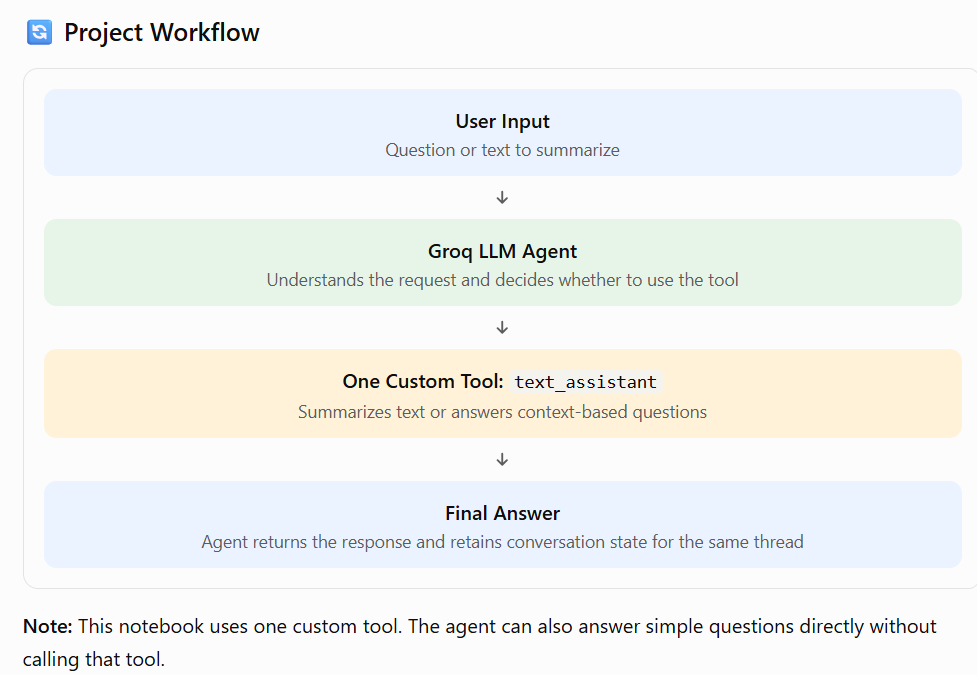